In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap
from feature_engineering import FeatureConstructor, OutlierHandler

In [8]:
df = pd.read_csv('train.csv')

In [9]:
df.sample(3)

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
139932,75,6.121195,459.089597,Standard,Mailed check,No,Both,No,Mobile,12.172608,58.147536,11,Fantasy,1.728248,2,Female,4,Yes,Yes,7XIGEVSV94,0
153408,94,16.891644,1587.814489,Standard,Credit card,Yes,TV Shows,Yes,TV,20.781642,114.731717,7,Drama,2.128992,0,Male,22,Yes,No,GVCQ6E1CFP,0
170139,111,5.518159,612.515639,Basic,Credit card,Yes,Both,No,Computer,32.108211,65.479665,44,Drama,3.126476,7,Male,20,Yes,Yes,97EUP7D8IW,0


In [10]:
df['SubscriptionType'].value_counts()

,count
SubscriptionType,
Standard,81920
Basic,81050
Premium,80817


In [11]:
df.describe()

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
count,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000,243787.000000
mean,60.083758,12.490695,750.741017,20.502179,92.264061,24.503513,3.002713,4.504186,12.018508,0.181232
std,34.285143,4.327615,523.073273,11.243753,50.505243,14.421174,1.155259,2.872548,7.193034,0.385211
min,1.000000,4.990062,4.991154,1.000065,5.000547,0.000000,1.000007,0.000000,0.000000,0.000000
25%,30.000000,8.738543,329.147027,10.763953,48.382395,12.000000,2.000853,2.000000,6.000000,0.000000
50%,60.000000,12.495555,649.878487,20.523116,92.249992,24.000000,3.002261,4.000000,12.000000,0.000000
75%,90.000000,16.238160,1089.317362,30.219396,135.908048,37.000000,4.002157,7.000000,18.000000,0.000000
max,119.000000,19.989957,2378.723844,39.999723,179.999275,49.000000,4.999989,9.000000,24.000000,1.000000


In [12]:
df = df.dropna()

In [45]:
df.duplicated().sum()

np.int64(0)

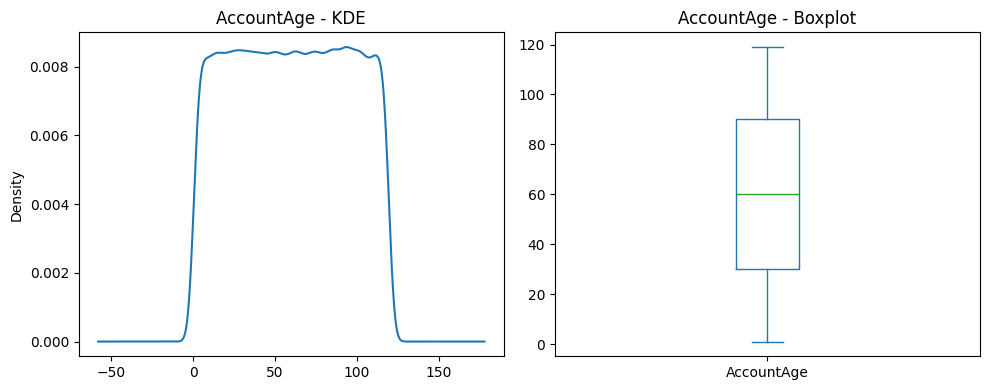

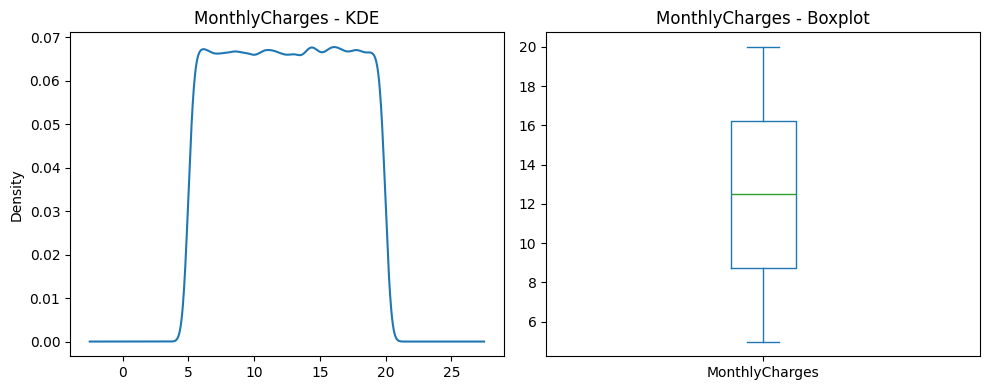

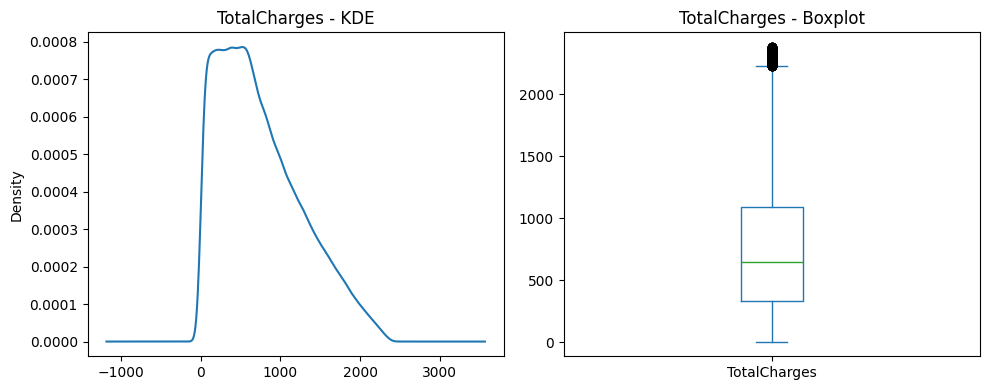

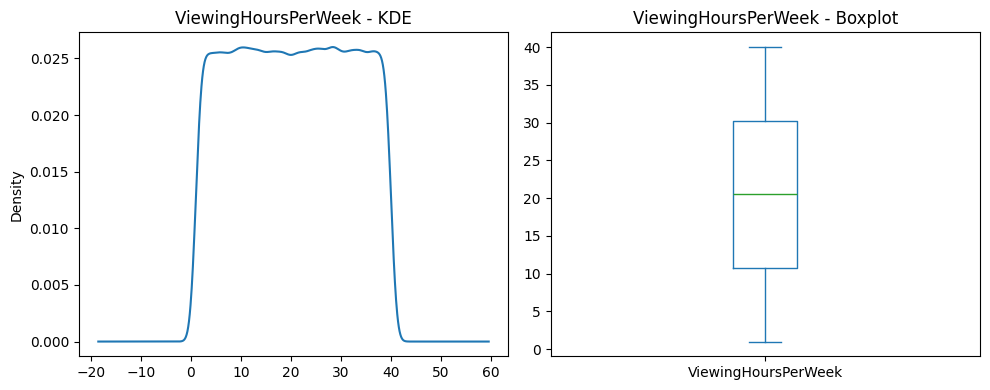

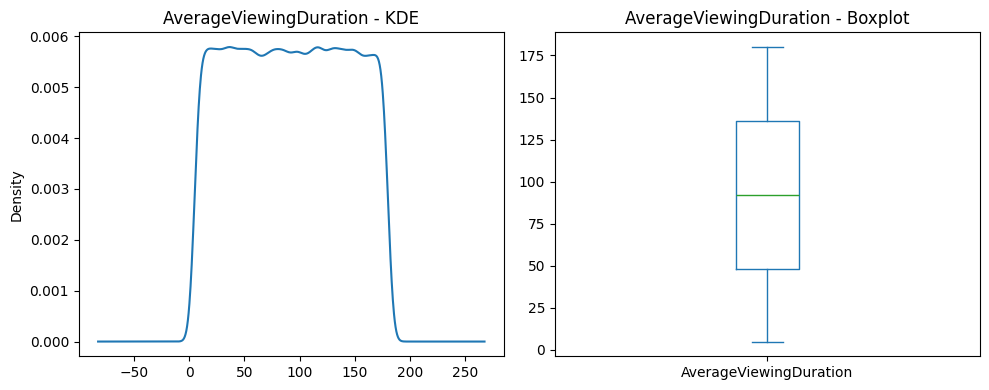

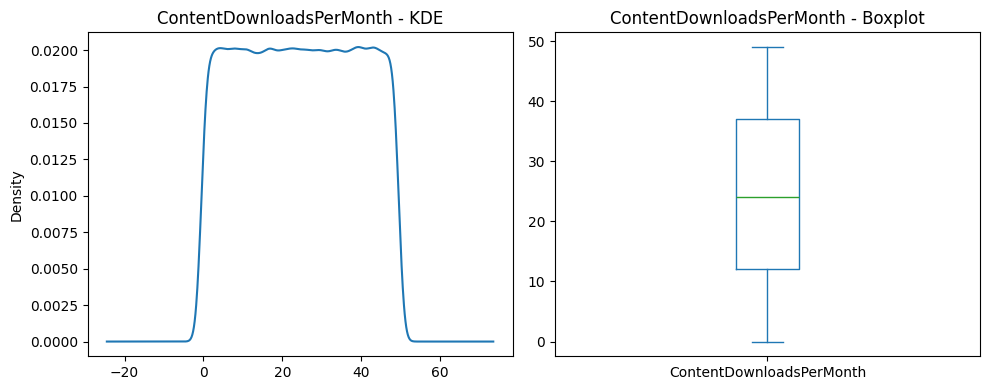

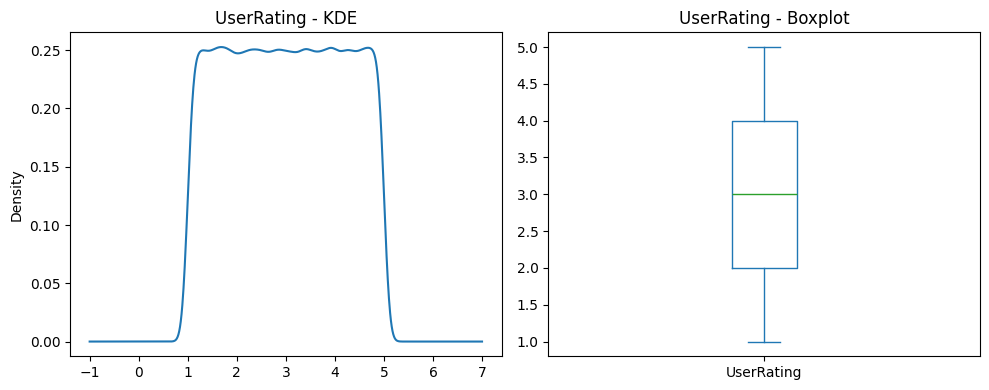

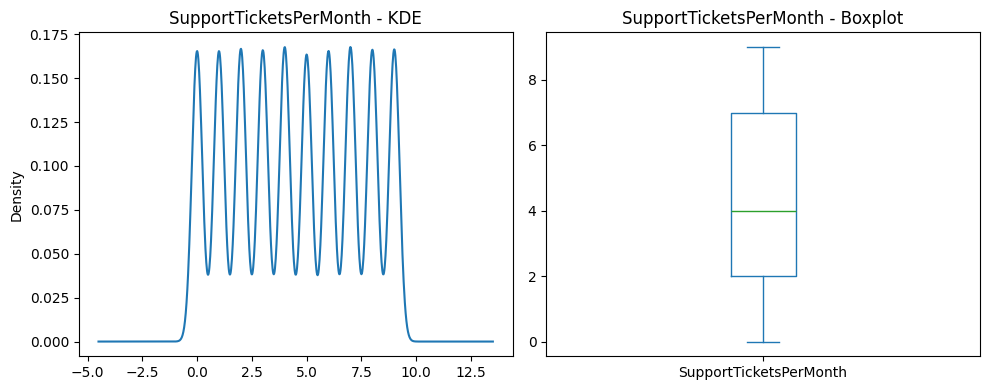

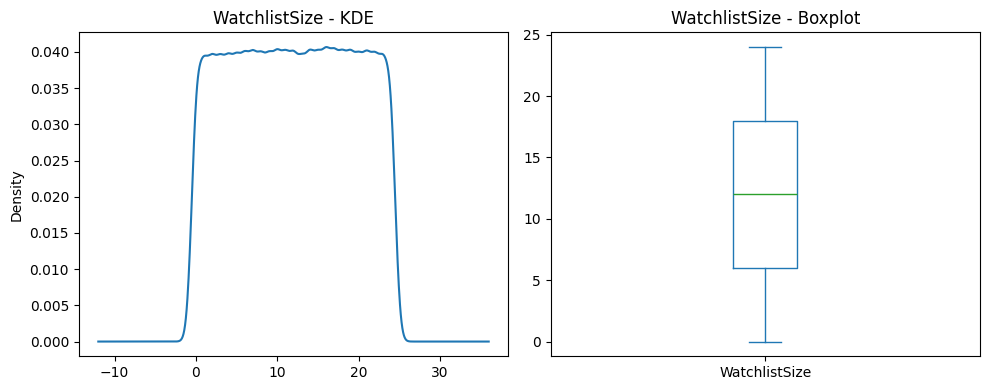

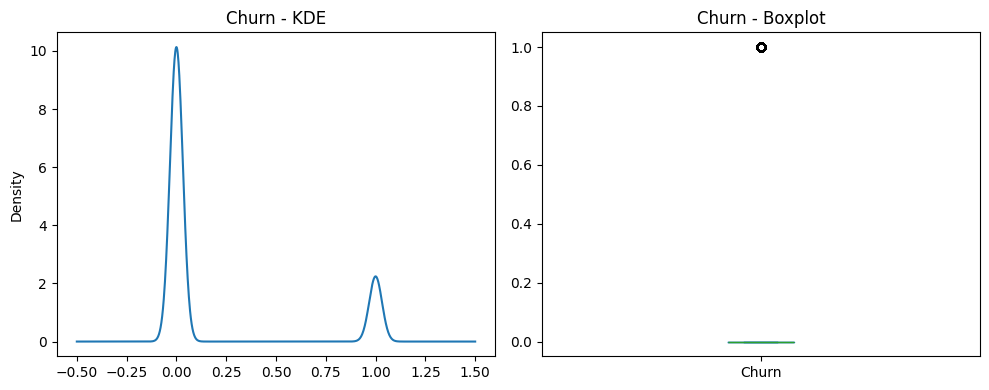

In [46]:
num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    df[col].plot(kind='kde')
    plt.title(f"{col} - KDE")
    plt.subplot(1, 2, 2)
    df[col].plot(kind='box')
    plt.title(f"{col} - Boxplot")
    plt.tight_layout()
    plt.show()

In [47]:
oh = OutlierHandler('TotalCharges')
oh.fit_transform(df)
oh.count_outliers(df)

741

In [48]:
df['Churn'].value_counts(normalize = True)

,proportion
Churn,
0,0.818768
1,0.181232


In [14]:
categorical_cols = list(df.select_dtypes(include=['object']).columns)
categorical_cols.remove('CustomerID')
categorical_cols

['SubscriptionType',
 'PaymentMethod',
 'PaperlessBilling',
 'ContentType',
 'MultiDeviceAccess',
 'DeviceRegistered',
 'GenrePreference',
 'Gender',
 'ParentalControl',
 'SubtitlesEnabled']

In [15]:
for col in categorical_cols:
  counts = df[col].value_counts()
  percent = df[col].value_counts(normalize=True) * 100
  result = pd.DataFrame({
        "Count": counts,
        "Percentage": percent.round(2)
  })
  print(result)


                  Count  Percentage
SubscriptionType                   
Standard          81920       33.60
Basic             81050       33.25
Premium           80817       33.15
                  Count  Percentage
PaymentMethod                      
Electronic check  61313       25.15
Credit card       60924       24.99
Bank transfer     60797       24.94
Mailed check      60753       24.92
                   Count  Percentage
PaperlessBilling                    
No                121980       50.04
Yes               121807       49.96
             Count  Percentage
ContentType                   
Both         81737       33.53
TV Shows     81145       33.29
Movies       80905       33.19
                    Count  Percentage
MultiDeviceAccess                    
No                 122035       50.06
Yes                121752       49.94
                  Count  Percentage
DeviceRegistered                   
Computer          61147       25.08
Tablet            61143       25.08
Mobil

In [16]:
def crosstab(df, target):
  for col in categorical_cols:
    ct = pd.crosstab(df[col], df[target], normalize='index') * 100
    print(ct.round(2))
    print()
    ct.plot(kind='bar', stacked=True, figsize=(6,4))
    plt.title(f"{col} vs {target}")
    plt.ylabel("Proportion")
    plt.show()


Churn                 0      1
SubscriptionType              
Basic             80.35  19.65
Premium           83.72  16.28
Standard          81.57  18.43



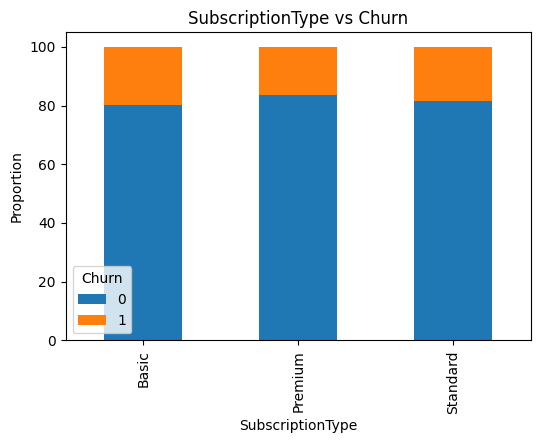

Churn                 0      1
PaymentMethod                 
Bank transfer     82.07  17.93
Credit card       83.77  16.23
Electronic check  80.75  19.25
Mailed check      80.91  19.09



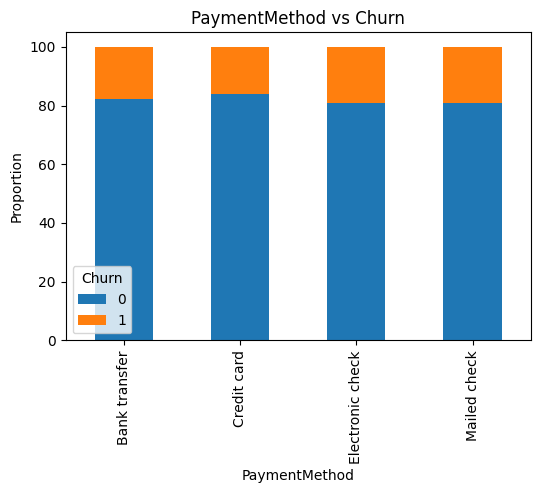

Churn                 0      1
PaperlessBilling              
No                81.84  18.16
Yes               81.91  18.09



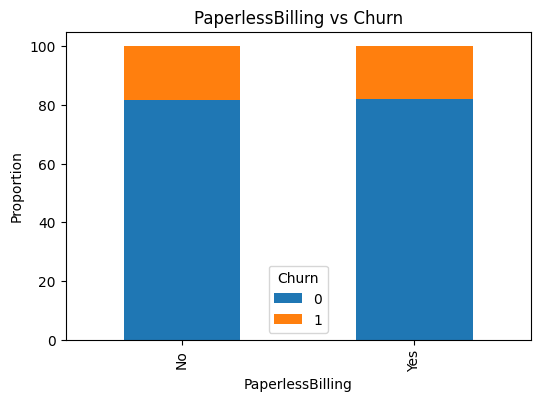

Churn            0      1
ContentType              
Both         81.15  18.85
Movies       82.22  17.78
TV Shows     82.26  17.74



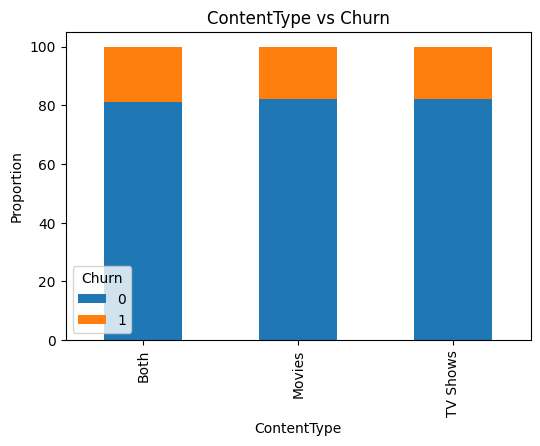

Churn                  0      1
MultiDeviceAccess              
No                 81.83  18.17
Yes                81.93  18.07



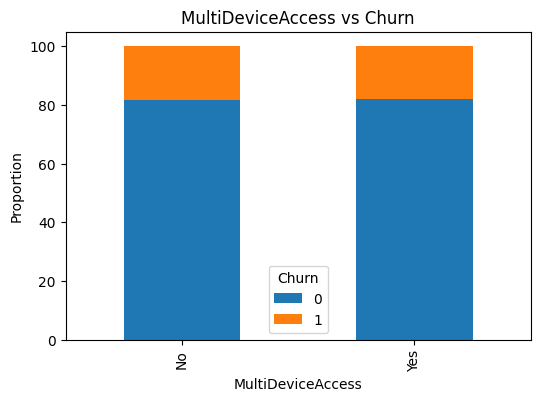

Churn                 0      1
DeviceRegistered              
Computer          81.87  18.13
Mobile            81.76  18.24
TV                82.10  17.90
Tablet            81.79  18.21



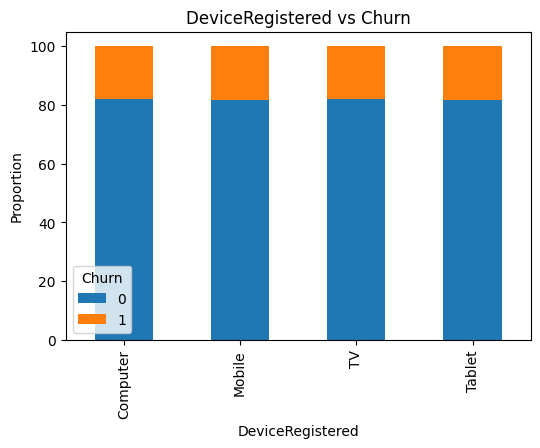

Churn                0      1
GenrePreference              
Action           83.41  16.59
Comedy           80.66  19.34
Drama            82.13  17.87
Fantasy          82.33  17.67
Sci-Fi           80.86  19.14



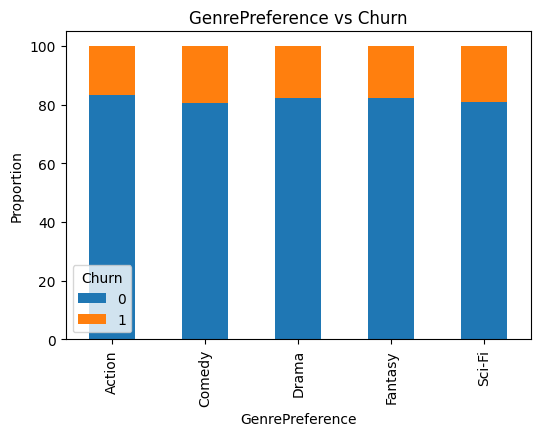

Churn       0      1
Gender              
Female  82.16  17.84
Male    81.59  18.41



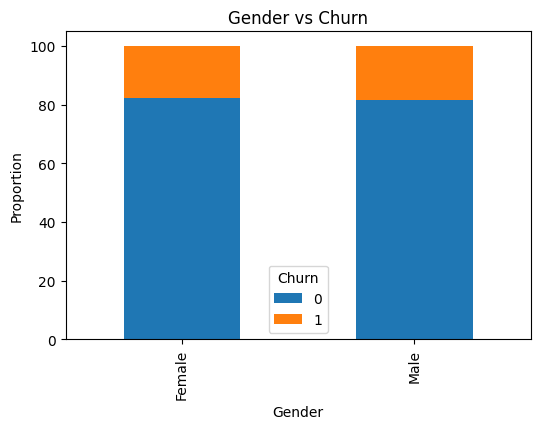

Churn                0      1
ParentalControl              
No               81.66  18.34
Yes              82.09  17.91



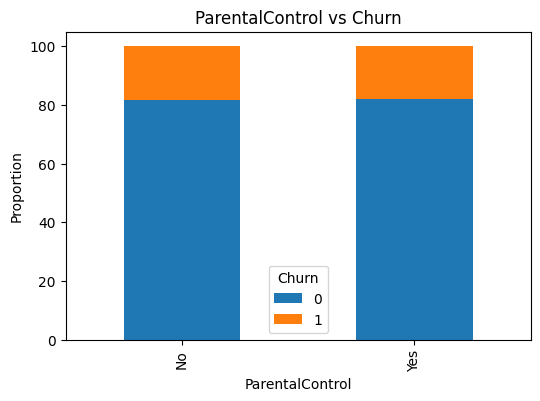

Churn                 0      1
SubtitlesEnabled              
No                81.40  18.60
Yes               82.35  17.65



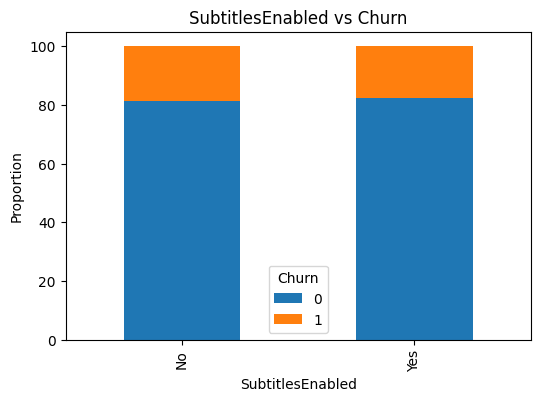

In [17]:
crosstab(df, 'Churn')

In [18]:
df.sample(3)

,AccountAge,MonthlyCharges,TotalCharges,SubscriptionType,PaymentMethod,PaperlessBilling,ContentType,MultiDeviceAccess,DeviceRegistered,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,GenrePreference,UserRating,SupportTicketsPerMonth,Gender,WatchlistSize,ParentalControl,SubtitlesEnabled,CustomerID,Churn
174053,29,5.144619,149.193950,Standard,Credit card,Yes,Movies,No,Computer,21.740771,17.240445,1,Drama,4.752377,1,Male,3,No,No,HOEGZDKDA5,1
146447,30,8.412763,252.382885,Basic,Electronic check,No,Both,No,Computer,18.595372,115.641520,0,Drama,2.314662,8,Female,20,No,Yes,9YJ29LCQ7N,1
31528,70,12.380561,866.639267,Basic,Mailed check,No,Both,No,Tablet,16.153284,106.048256,49,Fantasy,3.158993,4,Female,2,Yes,Yes,YJFKKCTNZ5,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243787 entries, 0 to 243786
Data columns (total 21 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   AccountAge                243787 non-null  int64  
 1   MonthlyCharges            243787 non-null  float64
 2   TotalCharges              243787 non-null  float64
 3   SubscriptionType          243787 non-null  object 
 4   PaymentMethod             243787 non-null  object 
 5   PaperlessBilling          243787 non-null  object 
 6   ContentType               243787 non-null  object 
 7   MultiDeviceAccess         243787 non-null  object 
 8   DeviceRegistered          243787 non-null  object 
 9   ViewingHoursPerWeek       243787 non-null  float64
 10  AverageViewingDuration    243787 non-null  float64
 11  ContentDownloadsPerMonth  243787 non-null  int64  
 12  GenrePreference           243787 non-null  object 
 13  UserRating                243787 non-null  f

In [20]:
numerical_col = list(df.select_dtypes(include=['float64','int64']).columns)
corr_matrix = df[numerical_col].corr()
corr_matrix

,AccountAge,MonthlyCharges,TotalCharges,ViewingHoursPerWeek,AverageViewingDuration,ContentDownloadsPerMonth,UserRating,SupportTicketsPerMonth,WatchlistSize,Churn
AccountAge,1.000000,0.001706,0.820144,-0.001640,0.000191,0.001220,0.000440,-0.002055,-0.002640,-0.197736
MonthlyCharges,0.001706,1.000000,0.498207,-0.003029,-0.000604,-0.000127,0.000056,0.000071,-0.000540,0.100473
TotalCharges,0.820144,0.498207,1.000000,-0.003006,0.000860,0.000208,0.000609,-0.001770,-0.001770,-0.120529
ViewingHoursPerWeek,-0.001640,-0.003029,-0.003006,1.000000,0.000949,0.002149,-0.003185,0.000788,-0.000750,-0.128645
AverageViewingDuration,0.000191,-0.000604,0.000860,0.000949,1.000000,-0.002397,-0.000406,-0.000158,0.000749,-0.146897
ContentDownloadsPerMonth,0.001220,-0.000127,0.000208,0.002149,-0.002397,1.000000,0.001294,-0.000497,0.002324,-0.129752
UserRating,0.000440,0.000056,0.000609,-0.003185,-0.000406,0.001294,1.000000,-0.000142,0.002567,0.022124
SupportTicketsPerMonth,-0.002055,0.000071,-0.001770,0.000788,-0.000158,-0.000497,-0.000142,1.000000,0.001250,0.084064
WatchlistSize,-0.002640,-0.000540,-0.001770,-0.000750,0.000749,0.002324,0.002567,0.001250,1.000000,0.021739
Churn,-0.197736,0.100473,-0.120529,-0.128645,-0.146897,-0.129752,0.022124,0.084064,0.021739,1.000000


In [49]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [50]:

transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), ['PaymentMethod', 'PaperlessBilling', 'ContentType', 'MultiDeviceAccess', 'DeviceRegistered', 'GenrePreference', 'Gender', 'ParentalControl', 'SubtitlesEnabled', 'premium_underuse','is_new_user']),
        ('ordinal', OrdinalEncoder(categories=[['Basic', 'Standard', 'Premium'], ['very_new','new','growing','loyal','veteran']]), ['SubscriptionType', 'loyalty_tier'])
    ],remainder = 'passthrough')


In [23]:
feature_constructor_eda = FeatureConstructor()
X_train_fc = feature_constructor_eda.fit_transform(X_train)

X_train_transformed = transformer.fit_transform(X_train_fc)
feature_names = transformer.get_feature_names_out()
transformed_x_train = pd.DataFrame(X_train_transformed, columns=feature_names)
transformed_x_train.head(3)


,encoder__PaymentMethod_Credit card,encoder__PaymentMethod_Electronic check,encoder__PaymentMethod_Mailed check,encoder__PaperlessBilling_Yes,encoder__ContentType_Movies,encoder__ContentType_TV Shows,encoder__MultiDeviceAccess_Yes,encoder__DeviceRegistered_Mobile,encoder__DeviceRegistered_TV,encoder__DeviceRegistered_Tablet,encoder__GenrePreference_Comedy,encoder__GenrePreference_Drama,encoder__GenrePreference_Fantasy,encoder__GenrePreference_Sci-Fi,encoder__Gender_Male,encoder__ParentalControl_Yes,encoder__SubtitlesEnabled_Yes,encoder__premium_underuse_1,encoder__is_new_user_1,ordinal__SubscriptionType,ordinal__loyalty_tier,remainder__AccountAge,remainder__MonthlyCharges,remainder__TotalCharges,remainder__ViewingHoursPerWeek,remainder__AverageViewingDuration,remainder__ContentDownloadsPerMonth,remainder__UserRating,remainder__SupportTicketsPerMonth,remainder__WatchlistSize,remainder__engagement_score,remainder__cost_per_hour,remainder__watch_intensity,remainder__support_to_usage,remainder__log_total_charges,remainder__watchlist_to_watch_ratio,remainder__session_depth,remainder__frustration_index
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,109.0,13.222629,1441.266608,16.911603,108.727123,41.0,1.365587,8.0,15.0,166.638726,0.738216,0.153742,0.446638,7.273971,0.837446,6.070206,37.075305
1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,2.0,1.0,7.0,15.282497,106.977477,6.513209,5.614800,36.0,4.716851,0.0,23.0,48.128010,2.034084,0.814151,0.000000,4.681923,3.061275,0.747324,0.000000
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,4.0,72.0,7.908776,569.431849,29.005506,83.297789,14.0,4.531153,4.0,12.0,126.303295,0.263577,0.397336,0.133309,6.346394,0.399927,2.776083,5.875386


In [51]:
transformed_x_train.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195029 entries, 0 to 195028
Data columns (total 38 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   encoder__PaymentMethod_Credit card       195029 non-null  float64
 1   encoder__PaymentMethod_Electronic check  195029 non-null  float64
 2   encoder__PaymentMethod_Mailed check      195029 non-null  float64
 3   encoder__PaperlessBilling_Yes            195029 non-null  float64
 4   encoder__ContentType_Movies              195029 non-null  float64
 5   encoder__ContentType_TV Shows            195029 non-null  float64
 6   encoder__MultiDeviceAccess_Yes           195029 non-null  float64
 7   encoder__DeviceRegistered_Mobile         195029 non-null  float64
 8   encoder__DeviceRegistered_TV             195029 non-null  float64
 9   encoder__DeviceRegistered_Tablet         195029 non-null  float64
 10  encoder__GenrePreference_Comedy 

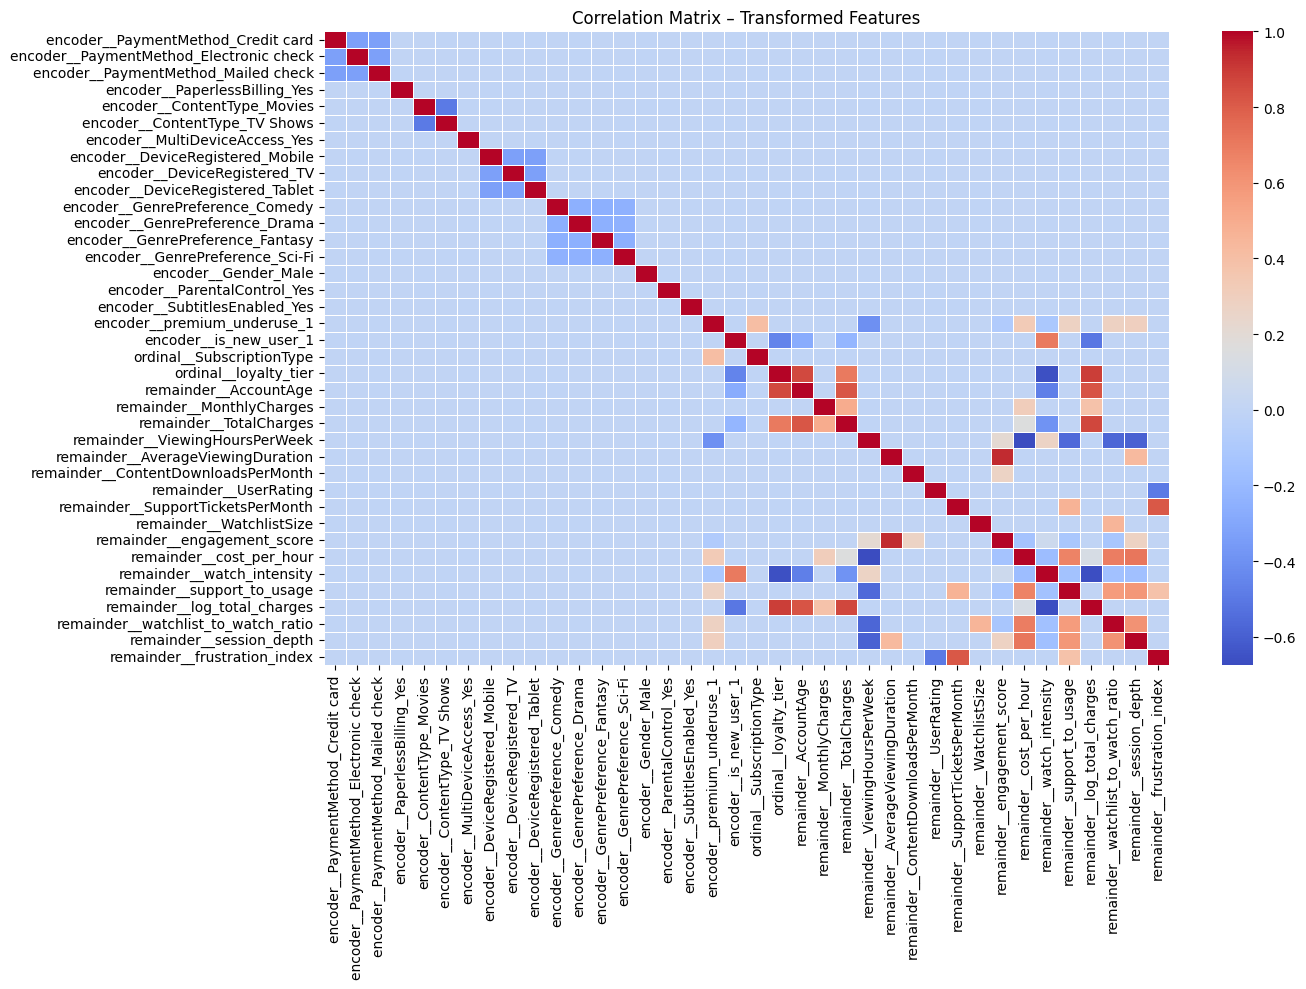

In [52]:
numerical_col = list(transformed_x_train.select_dtypes(include=['float64', 'int64']).columns)
corr_matrix = transformed_x_train[numerical_col].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix – Transformed Features')
plt.tight_layout()
plt.show()

In [55]:
pipeline = Pipeline([
    ('feature_constructor', FeatureConstructor()),
    ("outlier_handling", OutlierHandler('TotalCharges')),
    ('transformer', transformer),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression())
])

In [56]:
param_dist = [
    {
        'model': [LogisticRegression(max_iter=1000)],
        'model__C': [0.1, 1, 10],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model': [RandomForestClassifier()],
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 10, 20],
        'model__class_weight': [None, 'balanced']
    },
    {
        'model': [XGBClassifier(eval_metric='logloss')],
        'model__n_estimators': [100, 200],
        'model__max_depth': [3, 6],
        'model__learning_rate': [0.05, 0.1]
    },
    {
        'model': [LGBMClassifier()],
        'model__n_estimators': [100, 200],
        'model__num_leaves': [31, 50],
        'model__learning_rate': [0.05, 0.1]
    },
]


In [57]:
search = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, scoring='f1', cv=3, verbose=2, n_jobs=-1, random_state=42, error_score='raise')

search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, error_score='raise',
                   estimator=Pipeline(steps=[('feature_constructor',
                                              FeatureConstructor()),
                                             ('outlier_handling',
                                              OutlierHandler(column='TotalCharges')),
                                             ('transformer',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('encoder',
                                                                               OneHotEncoder(drop='first',
                                                                                             handle_unknown='ignore'),
                                                                               ['PaymentMethod',
                                                                                'PaperlessBilling',
                                                                                'Conte...
                                                                 monotone_constraints=None,
                                                                 multi_strategy=None,
                                                                 n_estimators=None,
                                                                 n_jobs=None,
                                                                 num_parallel_tree=None, ...)],
                                         'model__learning_rate': [0.05, 0.1],
                                         'model__max_depth': [3, 6],
                                         'model__n_estimators': [100, 200]},
                                        {'model': [LGBMClassifier()],
                                         'model__learning_rate': [0.05, 0.1],
                                         'model__n_estimators': [100, 200],
                                         'model__num_leaves': [31, 50]}],
                   random_state=42, scoring='f1', verbose=2)

In [58]:
best_model = search.best_estimator_
search.best_params_

{'model__class_weight': None,
 'model__C': 10,
 'model': LogisticRegression(max_iter=1000)}

In [59]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


In [60]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.67      0.77     39968
           1       0.32      0.69      0.44      8790

    accuracy                           0.68     48758
   macro avg       0.61      0.68      0.61     48758
weighted avg       0.80      0.68      0.71     48758



In [61]:
roc_auc_score(y_test, y_proba)

np.float64(0.7525262160809422)

In [62]:
confusion_matrix(y_test, y_pred)

array([[26971, 12997],
       [ 2687,  6103]])

In [64]:
for t in [1,0.9,0.8,0.7,0.6,0.5, 0.4, 0.3, 0.25, 0.2, 0.1, 0.05]:
    y_pred = (y_proba > t).astype(int)
    print(f"Threshold: {t}")
    print(confusion_matrix(y_test, y_pred))

Threshold: 1
[[39968     0]
 [ 8790     0]]
Threshold: 0.9
[[39869    99]
 [ 8569   221]]
Threshold: 0.8
[[38675  1293]
 [ 7344  1446]]
Threshold: 0.7
[[36028  3940]
 [ 5647  3143]]
Threshold: 0.6
[[32076  7892]
 [ 4037  4753]]
Threshold: 0.5
[[26971 12997]
 [ 2687  6103]]
Threshold: 0.4
[[21245 18723]
 [ 1595  7195]]
Threshold: 0.3
[[14752 25216]
 [  803  7987]]
Threshold: 0.25
[[11379 28589]
 [  495  8295]]
Threshold: 0.2
[[ 8089 31879]
 [  270  8520]]
Threshold: 0.1
[[ 2119 37849]
 [   31  8759]]
Threshold: 0.05
[[  379 39589]
 [    3  8787]]


In [65]:
for t in [0.4,0.39,0.38,0.37,0.36,0.35,0.34,0.33,0.32,0.31,0.30]:
    y_pred = (y_proba > t).astype(int)
    print(f"Threshold: {t}")
    print(confusion_matrix(y_test, y_pred))

Threshold: 0.4
[[21245 18723]
 [ 1595  7195]]
Threshold: 0.39
[[20640 19328]
 [ 1492  7298]]
Threshold: 0.38
[[20023 19945]
 [ 1398  7392]]
Threshold: 0.37
[[19368 20600]
 [ 1305  7485]]
Threshold: 0.36
[[18750 21218]
 [ 1228  7562]]
Threshold: 0.35
[[18128 21840]
 [ 1159  7631]]
Threshold: 0.34
[[17437 22531]
 [ 1080  7710]]
Threshold: 0.33
[[16747 23221]
 [ 1011  7779]]
Threshold: 0.32
[[16070 23898]
 [  941  7849]]
Threshold: 0.31
[[15413 24555]
 [  876  7914]]
Threshold: 0.3
[[14752 25216]
 [  803  7987]]


In [66]:
threshold = 0.35
y_pred_final = (y_proba >= threshold).astype(int)

In [67]:

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.94      0.45      0.61     39968
           1       0.26      0.87      0.40      8790

    accuracy                           0.53     48758
   macro avg       0.60      0.66      0.51     48758
weighted avg       0.82      0.53      0.57     48758



In [68]:
import time

start = time.time()
best_model.predict(X_test)
print("Time:", time.time() - start)

Time: 0.3250880241394043


In [69]:
import joblib

joblib.dump({
    "model": best_model,
    "threshold": 0.35
}, "churn_model.pkl")

['churn_model.pkl']

In [75]:
fc = best_model.named_steps["feature_constructor"]
oh = best_model.named_steps["outlier_handling"]
preprocessor = best_model.named_steps["transformer"]
X_test_fc = fc.transform(X_test)
X_test_fc = oh.transform(X_test_fc)
X_test_transformed = preprocessor.transform(X_test_fc)

In [76]:
feature_names = preprocessor.get_feature_names_out()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

In [77]:
model = best_model.named_steps['model']
transformer = best_model.named_steps['transformer']
feature_constructor = best_model.named_steps['feature_constructor']

In [78]:
X_sample = X_test.sample(300, random_state=42)
X_fc = feature_constructor.transform(X_sample)
X_transformed = transformer.transform(X_fc)

In [79]:
feature_names = transformer.get_feature_names_out()

In [80]:
explainer = shap.Explainer(model, X_test_transformed_df)
shap_values = explainer(X_test_transformed_df)

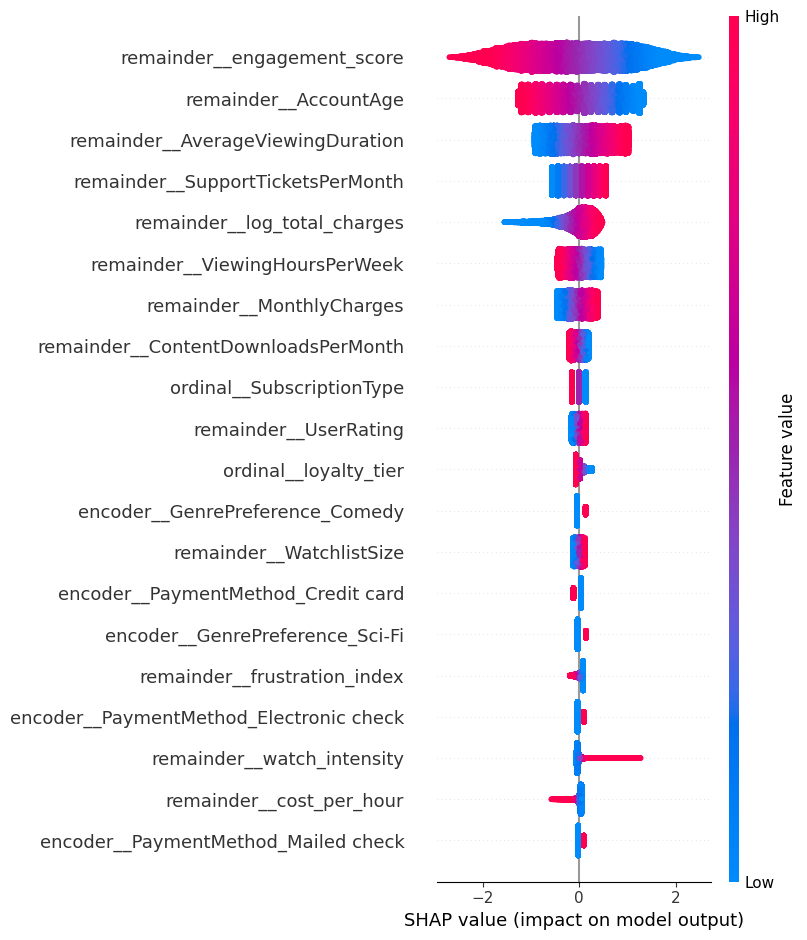

In [82]:
shap.summary_plot(shap_values, X_test_transformed_df, feature_names=feature_names)

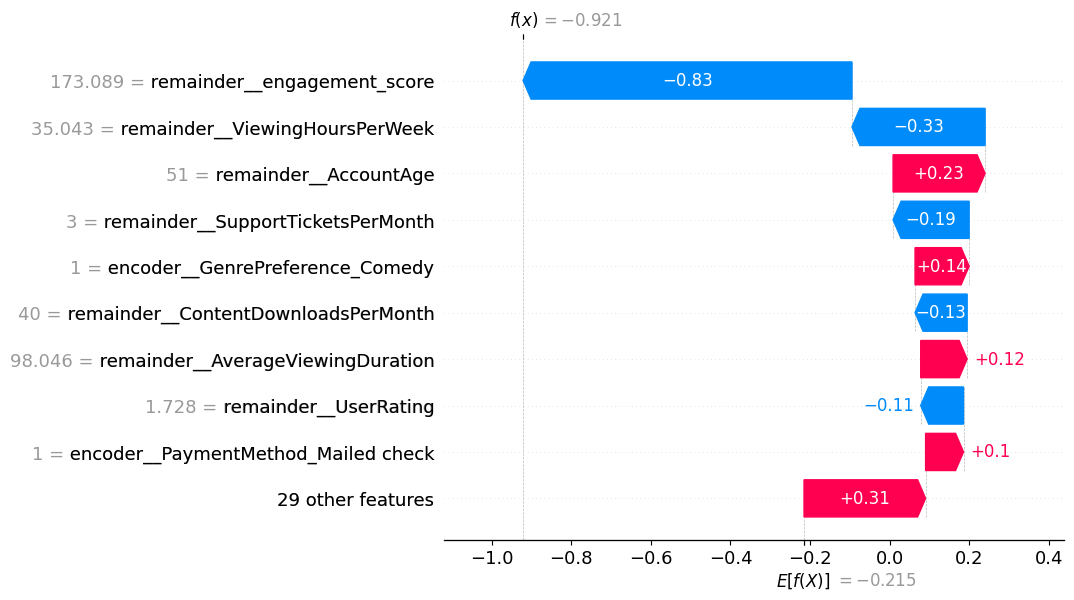

In [83]:
shap.plots.waterfall(shap_values[0])

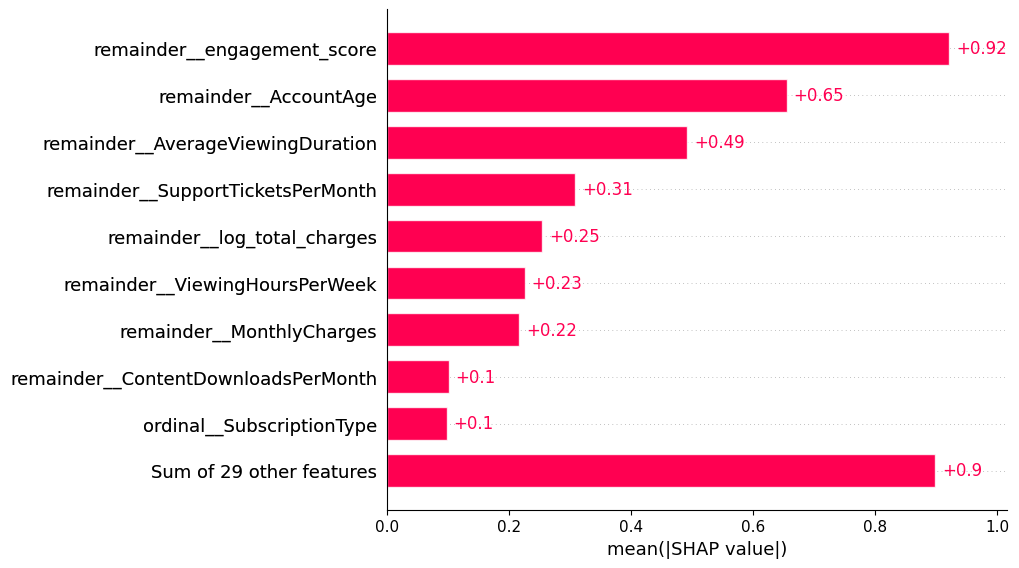

In [84]:
shap.plots.bar(shap_values)